# Statistic correlation analysis


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    # update for your local path
    %cd /home/jacob/kalnet


/home/jacob/kalnet


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from kalnet.task_vec import KalmanFilteringTask
from kalnet.model import KalmanRNN
from kalnet.correlation import correlate_hidden_stats


## Data collection

Collects hidden-layer activity and Opt variance for train/test Trials from
`checkpoints/kf_allgain_100batch.pt`. Dataset:
`saved_data/kf_allgain_100batch_dataset.pt`.


In [3]:
def collect(task: KalmanFilteringTask, net: KalmanRNN, n_trials: int, device: str = "cpu"):
    """Collect hidden states + ground truth for n_trials, in chunks of task.batch_size.
    Expects task_vec.KalmanFilteringTask (tensor batches).
    """
    net.eval()
    all_r_hid, all_s, all_g, all_mu, all_sigma_sq, all_s_hat = [], [], [], [], [], []

    n_collected = 0
    with torch.no_grad():
        while n_collected < n_trials:
            batch = task.sample(include_internals=True)

            y, hidden = net(batch.input.to(device), return_hidden=True)
            # squeeze away the trailing singleton feature dim to match this
            # project's (n_trials, T) convention throughout
            s_hat = y[:, :, 0]
            s = batch.target[:, :, 0].to(device)
            g = batch.internals.gain[:, :, 0].to(device)
            mu = batch.opt_mean[:, :, 0].to(device)
            sigma_sq = batch.internals.opt_var[:, :, 0].to(device)

            all_r_hid.append(hidden.cpu())
            all_s.append(s.cpu())
            all_g.append(g.cpu())
            all_mu.append(mu.cpu())
            all_sigma_sq.append(sigma_sq.cpu())
            all_s_hat.append(s_hat.cpu())

            n_collected += batch.input.shape[0]  # = task.batch_size, each call

    return {
        "r_hid": torch.cat(all_r_hid, dim=0)[:n_trials],
        "s": torch.cat(all_s, dim=0)[:n_trials],
        "g": torch.cat(all_g, dim=0)[:n_trials],
        "mu": torch.cat(all_mu, dim=0)[:n_trials],
        "sigma_sq": torch.cat(all_sigma_sq, dim=0)[:n_trials],
        "s_hat": torch.cat(all_s_hat, dim=0)[:n_trials],
    }


In [5]:
device = "cpu"
checkpoint = torch.load(
    "checkpoints/kf_allgain_100batch.pt",
    map_location=device,
    weights_only=False,
)
net = KalmanRNN(
    n_in=checkpoint["config"]["n_in"],
    n_hid=checkpoint["config"]["n_hid"],
    n_out=1,
).to(device)
net.load_state_dict(checkpoint["state_dict"])
print("Loaded trained network.")

train_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=1000, device=device)
test_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=2000, device=device)

print("Collecting training set...")
train_data = collect(train_task, net, n_trials=5000, device=device)

print("Collecting held-out test set...")
test_data = collect(test_task, net, n_trials=2000, device=device)

torch.save({"train": train_data, "test": test_data, "checkpoint_path": "checkpoints/kf_allgain_100batch.pt"}, "saved_data/kf_allgain_100batch_dataset.pt")
print("Saved saved_data/kf_allgain_100batch_dataset.pt")
print(f"  train: r_hid {train_data['r_hid'].shape}")
print(f"  test:  r_hid {test_data['r_hid'].shape}")


Loaded trained network.
Saved saved_data/kf_dataset_100.pt
  train: r_hid torch.Size([5000, 25, 200])
  test:  r_hid torch.Size([2000, 25, 200])


## Mean activity and Kurtosis vs Opt variance

**Statistic correlation** of hidden-layer summaries with Opt variance on the held-out test Trials (no Decoder).


In [6]:
dataset = torch.load("saved_data/kf_allgain_100batch_dataset.pt", map_location="cpu", weights_only=False)
test = dataset["test"]
result = correlate_hidden_stats(test["r_hid"], test["sigma_sq"])

print(f"Pooled test samples: {len(result.opt_variance):,}")
print(f"corr(mean activity, Opt variance):  r={result.r_mean:+.4f}  p={result.p_mean:.2e}")
print(f"corr(kurtosis,      Opt variance):  r={result.r_kurtosis:+.4f}  p={result.p_kurtosis:.2e}")

if abs(result.r_mean) > abs(result.r_kurtosis) * 1.5:
    verdict = "MEAN-ACTIVITY code looks dominant"
elif abs(result.r_kurtosis) > abs(result.r_mean) * 1.5:
    verdict = "SPARSITY code looks dominant"
else:
    verdict = "BOTH statistics show comparable correlation — inconclusive from this alone"
print(f"--> {verdict}")


Pooled test samples: 50,000
corr(mean activity, Opt variance):  r=+0.0023  p=6.01e-01
corr(kurtosis,      Opt variance):  r=-0.6486  p=0.00e+00
--> SPARSITY code looks dominant


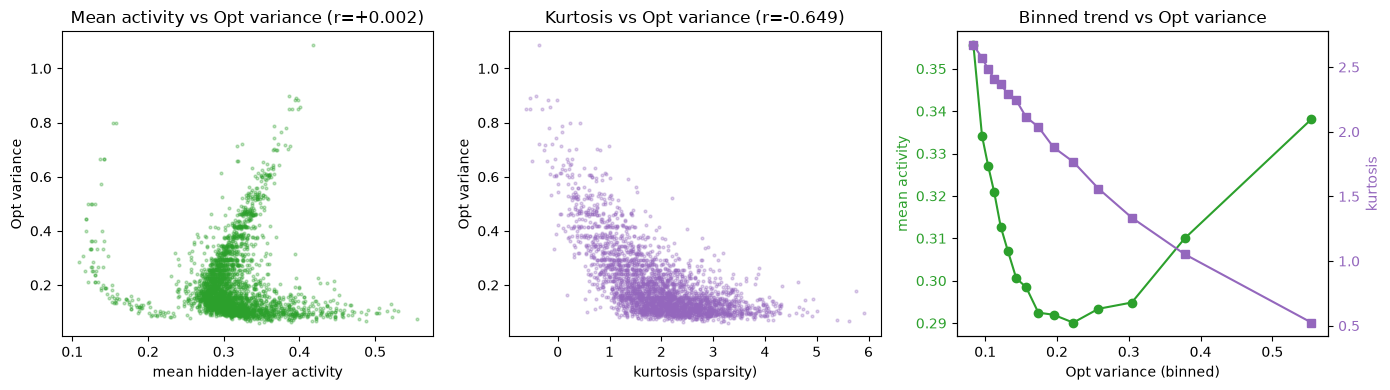

In [7]:
rng = np.random.default_rng(0)
n_plot = min(3000, len(result.opt_variance))
idx = rng.choice(len(result.opt_variance), size=n_plot, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(
    result.mean_activity[idx], result.opt_variance[idx], s=4, alpha=0.3, color="tab:green"
)
axes[0].set_xlabel("mean hidden-layer activity")
axes[0].set_ylabel("Opt variance")
axes[0].set_title(f"Mean activity vs Opt variance (r={result.r_mean:+.3f})")

axes[1].scatter(
    result.kurtosis[idx], result.opt_variance[idx], s=4, alpha=0.3, color="tab:purple"
)
axes[1].set_xlabel("kurtosis (sparsity)")
axes[1].set_ylabel("Opt variance")
axes[1].set_title(f"Kurtosis vs Opt variance (r={result.r_kurtosis:+.3f})")

n_bins = 15
bin_edges = np.quantile(result.opt_variance, np.linspace(0, 1, n_bins + 1))
bin_idx = np.digitize(result.opt_variance, bin_edges[1:-1])
bin_centers, mean_act_binned, kurt_binned = [], [], []
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_centers.append(result.opt_variance[mask].mean())
        mean_act_binned.append(result.mean_activity[mask].mean())
        kurt_binned.append(result.kurtosis[mask].mean())

ax = axes[2]
ax.plot(bin_centers, mean_act_binned, "o-", color="tab:green", label="mean activity")
ax.set_xlabel("Opt variance (binned)")
ax.set_ylabel("mean activity", color="tab:green")
ax.tick_params(axis="y", labelcolor="tab:green")
ax2 = ax.twinx()
ax2.plot(bin_centers, kurt_binned, "s-", color="tab:purple", label="kurtosis")
ax2.set_ylabel("kurtosis", color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")
ax.set_title("Binned trend vs Opt variance")

plt.tight_layout()
plt.show()


## All-gain 10-batch checkpoint (comparison)

Same collection + statistic correlation, but on `checkpoints/kf_allgain_10batch.pt`. This is the run that showed a surprisingly strong **mean activity vs Opt variance** correlation. The 10-batch model was trained differently than batch-100, so the difference may just reflect training recipe.


In [9]:
ten_checkpoint = torch.load(
    "checkpoints/kf_allgain_10batch.pt",
    map_location=device,
    weights_only=False,
)
ten_net = KalmanRNN(
    n_in=ten_checkpoint["config"]["n_in"],
    n_hid=ten_checkpoint["config"]["n_hid"],
    n_out=1,
).to(device)
ten_net.load_state_dict(ten_checkpoint["state_dict"])
print("Loaded allgain_10batch network.")

print("Collecting held-out test set...")
ten_test_data = collect(test_task, ten_net, n_trials=2000, device=device)

torch.save({"test": ten_test_data, "checkpoint_path": "checkpoints/kf_allgain_10batch.pt"}, "saved_data/kf_allgain_10batch_dataset.pt")
print("Saved saved_data/kf_allgain_10batch_dataset.pt")
print(f"  test:  r_hid {ten_test_data['r_hid'].shape}")


Loaded default network.
Saved saved_data/kf_dataset_default.pt
  test:  r_hid torch.Size([2000, 25, 200])


In [10]:
ten_dataset = torch.load(
    "saved_data/kf_allgain_10batch_dataset.pt", map_location="cpu", weights_only=False
)
ten_test = ten_dataset["test"]
ten_result = correlate_hidden_stats(ten_test["r_hid"], ten_test["sigma_sq"])

print(f"Pooled test samples: {len(ten_result.opt_variance):,}")
print(f"corr(mean activity, Opt variance):  r={ten_result.r_mean:+.4f}  p={ten_result.p_mean:.2e}")
print(f"corr(kurtosis,      Opt variance):  r={ten_result.r_kurtosis:+.4f}  p={ten_result.p_kurtosis:.2e}")

print("\n--- allgain_10batch vs allgain_100batch ---")
print(f"mean activity:  10batch r={ten_result.r_mean:+.4f}   100batch r={result.r_mean:+.4f}")
print(f"kurtosis:       10batch r={ten_result.r_kurtosis:+.4f}   100batch r={result.r_kurtosis:+.4f}")


Pooled test samples: 50,000
corr(mean activity, Opt variance):  r=+0.3524  p=0.00e+00
corr(kurtosis,      Opt variance):  r=-0.7265  p=0.00e+00

--- default vs batch-100 ---
mean activity:  default r=+0.3524   batch100 r=+0.0023
kurtosis:       default r=-0.7265   batch100 r=-0.6486


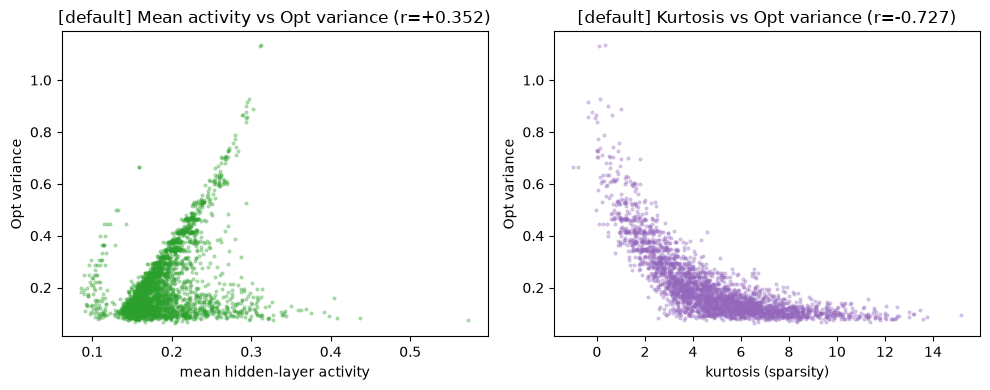

In [11]:
rng = np.random.default_rng(0)
n_plot = min(3000, len(ten_result.opt_variance))
idx = rng.choice(len(ten_result.opt_variance), size=n_plot, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(
    ten_result.mean_activity[idx], ten_result.opt_variance[idx], s=4, alpha=0.3, color="tab:green"
)
axes[0].set_xlabel("mean hidden-layer activity")
axes[0].set_ylabel("Opt variance")
axes[0].set_title(f"[allgain_10batch] Mean activity vs Opt variance (r={ten_result.r_mean:+.3f})")

axes[1].scatter(
    ten_result.kurtosis[idx], ten_result.opt_variance[idx], s=4, alpha=0.3, color="tab:purple"
)
axes[1].set_xlabel("kurtosis (sparsity)")
axes[1].set_ylabel("Opt variance")
axes[1].set_title(f"[allgain_10batch] Kurtosis vs Opt variance (r={ten_result.r_kurtosis:+.3f})")

plt.tight_layout()
plt.show()
